In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install timm==0.9.12
!pip install matplotlib seaborn scikit-learn h5py


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import timm
import os
import h5py

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
torch.cuda.is_available(), torch.cuda.get_device_name(0)


Using device: cuda


(True, 'Tesla T4')

In [4]:
config = {
    "batch_size": 8,
    "epochs": 25,
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "img_size": 256,
    "dropout": 0.2,
    "num_workers": 2
}


In [5]:
DATASET_ROOT = "/content/drive/MyDrive/morph_project/processed"

TRAIN_H5 = os.path.join(DATASET_ROOT, "train.h5")
TEST_H5  = os.path.join(DATASET_ROOT,  "test.h5")

print("Train:", TRAIN_H5)
print("Test:", TEST_H5)


Train: /content/drive/MyDrive/morph_project/processed/train.h5
Test: /content/drive/MyDrive/morph_project/processed/test.h5


In [6]:
with h5py.File(TRAIN_H5, 'r') as f:
    X_train_full = np.array(f["X"])
    y_train_full = np.array(f["y"])

with h5py.File(TEST_H5, 'r') as f:
    X_test = np.array(f["X"])
    y_test = np.array(f["y"])

print("Train full:", X_train_full.shape, y_train_full.shape)
print("Test:", X_test.shape, y_test.shape)


Train full: (7177, 224, 224, 3) (7177,)
Test: (1803, 224, 224, 3) (1803,)


In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)


Train: (5741, 224, 224, 3)
Val: (1436, 224, 224, 3)
Test: (1803, 224, 224, 3)


In [8]:
class NumpyDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx].astype(np.uint8)
        img = transforms.ToPILImage()(img)
        label = int(self.y[idx])
        if self.transform:
            img = self.transform(img)
        return img, label


In [9]:
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])


In [10]:
train_dataset = NumpyDataset(X_train, y_train, transform_train)
val_dataset   = NumpyDataset(X_val, y_val, transform_test)
test_dataset  = NumpyDataset(X_test, y_test, transform_test)

train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True, num_workers=config["num_workers"])
val_loader   = DataLoader(val_dataset, batch_size=config["batch_size"], shuffle=False, num_workers=config["num_workers"])
test_loader  = DataLoader(test_dataset, batch_size=config["batch_size"], shuffle=False, num_workers=config["num_workers"])

print("Dataloaders ready!")


Dataloaders ready!


In [11]:
images, labels = next(iter(train_loader))
print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)


Batch image shape: torch.Size([8, 3, 256, 256])
Batch label shape: torch.Size([8])


In [12]:
class SwinV2Classifier(nn.Module):
    def __init__(self, num_classes=2, dropout=0.2):
        super(SwinV2Classifier, self).__init__()

        # Lightweight SwinV2 model (tiny variant)
        self.backbone = timm.create_model(
            "swinv2_tiny_window16_256",
            pretrained=True,
            num_classes=0
        )

        in_features = self.backbone.num_features

        self.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        out = self.classifier(features)
        return out


model = SwinV2Classifier(num_classes=2, dropout=config["dropout"]).to(device)


/usr/local/lib/python3.12/dist-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
sum(p.numel() for p in model.parameters() if p.requires_grad)


27775532

In [13]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=config["lr"],
    weight_decay=config["weight_decay"]
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config["epochs"]
)


In [14]:
def calculate_accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return (preds == labels).float().mean().item()


In [15]:
torch.cuda.empty_cache()


In [16]:
scaler = torch.cuda.amp.GradScaler()

train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_acc = 0
best_model_path = "/content/drive/MyDrive/morph_project/swinv2_best.pth"

for epoch in range(config["epochs"]):
    model.train()
    running_loss = 0
    running_acc = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        running_acc += calculate_accuracy(outputs, labels)

    train_losses.append(running_loss / len(train_loader))
    train_accs.append(running_acc / len(train_loader))

    # Validation
    model.eval()
    val_loss = 0
    val_acc = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            val_acc += calculate_accuracy(outputs, labels)

    val_losses.append(val_loss / len(val_loader))
    val_accs.append(val_acc / len(val_loader))

    if val_accs[-1] > best_val_acc:
        best_val_acc = val_accs[-1]
        torch.save(model.state_dict(), best_model_path)

    scheduler.step()

    print(f"Epoch [{epoch+1}/{config['epochs']}]: "
          f"Train Loss: {train_losses[-1]:.4f}, "
          f"Train Acc: {train_accs[-1]:.4f}, "
          f"Val Loss: {val_losses[-1]:.4f}, "
          f"Val Acc: {val_accs[-1]:.4f}")


/tmp/ipython-input-78890690.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipython-input-78890690.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipython-input-78890690.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [1/25]: Train Loss: 0.4679, Train Acc: 0.8280, Val Loss: 0.4431, Val Acc: 0.8292
Epoch [2/25]: Train Loss: 0.4562, Train Acc: 0.8284, Val Loss: 0.4481, Val Acc: 0.8292
Epoch [3/25]: Train Loss: 0.4489, Train Acc: 0.8284, Val Loss: 0.4409, Val Acc: 0.8292
Epoch [4/25]: Train Loss: 0.4448, Train Acc: 0.8282, Val Loss: 0.4389, Val Acc: 0.8292
Epoch [5/25]: Train Loss: 0.4380, Train Acc: 0.8283, Val Loss: 0.4330, Val Acc: 0.8292
Epoch [6/25]: Train Loss: 0.4329, Train Acc: 0.8279, Val Loss: 0.4282, Val Acc: 0.8285
Epoch [7/25]: Train Loss: 0.4241, Train Acc: 0.8281, Val Loss: 0.4426, Val Acc: 0.8257
Epoch [8/25]: Train Loss: 0.4052, Train Acc: 0.8369, Val Loss: 0.4115, Val Acc: 0.8347
Epoch [9/25]: Train Loss: 0.3865, Train Acc: 0.8425, Val Loss: 0.3985, Val Acc: 0.8444
Epoch [10/25]: Train Loss: 0.3628, Train Acc: 0.8500, Val Loss: 0.4046, Val Acc: 0.8479
Epoch [11/25]: Train Loss: 0.3310, Train Acc: 0.8631, Val Loss: 0.4083, Val Acc: 0.8271
Epoch [12/25]: Train Loss: 0.3000, Train 

In [ ]:
import os

path = "/content/drive/MyDrive/morph_project"

print(os.listdir(path))


['datasets', 'models', 'efficientnet_b3_casia.pth', 'extracted_datasets', 'extracted', 'processed', 'processed_new', 'convnextv2_best.pth', 'swinv2_best.pth']


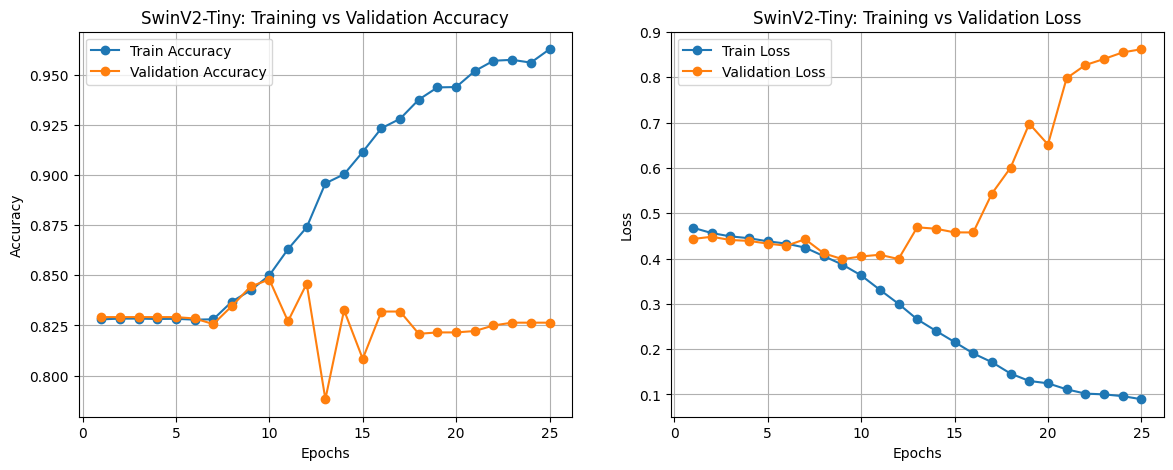

In [17]:
import matplotlib.pyplot as plt

epochs = range(1, config["epochs"] + 1)

plt.figure(figsize=(14,5))

# ---- Accuracy ----
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accs, label='Train Accuracy', marker='o')
plt.plot(epochs, val_accs, label='Validation Accuracy', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('SwinV2-Tiny: Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

# ---- Loss ----
plt.subplot(1, 2, 2)
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('SwinV2-Tiny: Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.show()


In [18]:
import numpy as np

np.save("/content/drive/MyDrive/morph_project/swinv2_train_acc.npy", np.array(train_accs))
np.save("/content/drive/MyDrive/morph_project/swinv2_val_acc.npy", np.array(val_accs))
np.save("/content/drive/MyDrive/morph_project/swinv2_train_loss.npy", np.array(train_losses))
np.save("/content/drive/MyDrive/morph_project/swinv2_val_loss.npy", np.array(val_losses))

print("SwinV2 training logs saved successfully!")


SwinV2 training logs saved successfully!


In [19]:
best_model = SwinV2Classifier(num_classes=2, dropout=config["dropout"]).to(device)
best_model.load_state_dict(torch.load(best_model_path))
best_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, digits=4))

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))



Classification Report:
              precision    recall  f1-score   support

           0     0.8549    0.9731    0.9102      1489
           1     0.6296    0.2166    0.3223       314

    accuracy                         0.8414      1803
   macro avg     0.7422    0.5948    0.6162      1803
weighted avg     0.8156    0.8414    0.8078      1803


Confusion Matrix:
[[1449   40]
 [ 246   68]]


In [26]:
from google.colab import files
from PIL import Image

def predict_image(model, img_path):
    img = Image.open(img_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((config["img_size"], config["img_size"])),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
    ])

    img_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    class_names = ["Licit", "Illicit"]
    print(f"Prediction: {class_names[pred]}")
    print("Confidence:", probs[0][pred].item())

# Upload image
uploaded = files.upload()

for filename in uploaded.keys():
    predict_image(best_model, filename)


Saving img4.png to img4.png
Prediction: Licit
Confidence: 0.9855642914772034
